8장 생성 모델

In [ ]:
# 예제 8.1 오토 인코더(Fashion_MNIST 재구성)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
transform = transforms.ToTensor()   # 텐서 변환/정규화(0 ~ 1)

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True,
                                      transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True,
                                     transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 인코더 정의
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense = nn.Linear(28 * 28, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.dense(x))
        return x

In [ ]:
# 디코더 정의
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.dense = nn.Linear(latent_dim, 28 * 28)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.dense(x))
        x = x.view(-1, 1, 28, 28)
        return x

In [ ]:
# 오토인코더 정의
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 모델 생성
model = AutoEncoder(latent_dim=32).to(device)

In [ ]:
print(model)

AutoEncoder(
  (encoder): Encoder(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (dense): Linear(in_features=784, out_features=32, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (dense): Linear(in_features=32, out_features=784, bias=True)
    (sigmoid): Sigmoid()
  )
)


In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.MSELoss()   # 손실 함수로 MSE 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 5
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for images, _ in train_loader:   # 레이블은 사용하지 않음
        images = images.to(device)
        outputs = model(images)   # 출력 계산
        loss = loss_fn(outputs, images)   # 손실 계산(입력을 레이블로 사용)

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장

    print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")

Epoch 1 	 loss: 0.0353
Epoch 2 	 loss: 0.0193
Epoch 3 	 loss: 0.0175
Epoch 4 	 loss: 0.0170
Epoch 5 	 loss: 0.0166


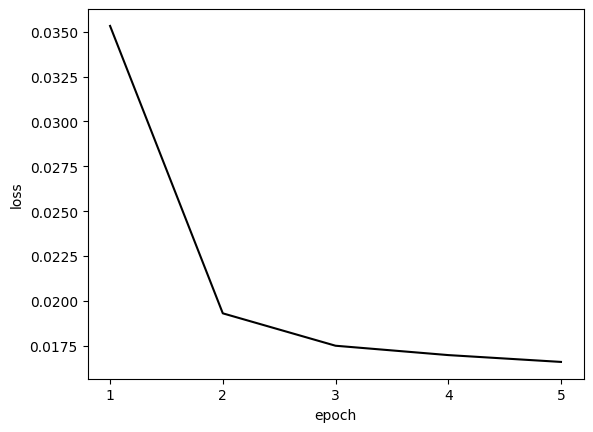

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, epochs + 1), losses, color="black")
plt.xticks(range(1, epochs + 1))
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

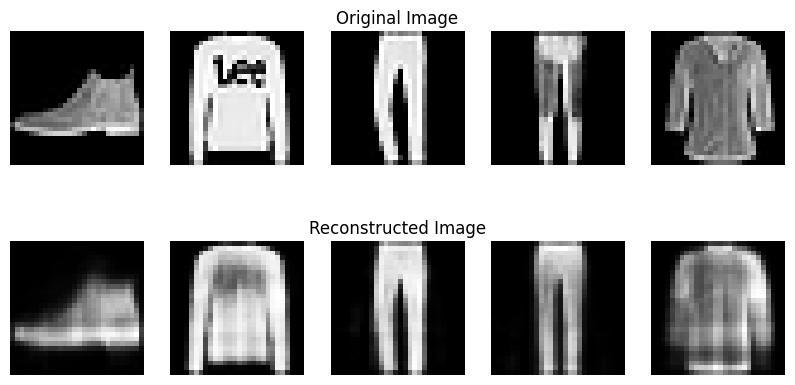

In [ ]:
# 재구성 이미지 시각화
model.eval()   # 평가 모드

with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
    images, _ = next(iter(test_loader))   # 레이블은 사용하지 않음
    images = images[:5].to(device)
    predicted = model(images)   # 예측(재구성 이미지)

plt.figure(figsize=(10, 5))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")    # 원본 이미지
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(predicted[i].cpu().squeeze(), cmap="gray")   # 재구성 이미지
    plt.axis("off")

plt.subplot(2, 5, 3).set_title("Original Image")
plt.subplot(2, 5, 8).set_title("Reconstructed Image")

plt.show()

In [ ]:
# 예제 8.2 VAE 숫자 생성 소규모 MNIST

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
transform = transforms.ToTensor()   # 텐서 변환/정규화(0 ~ !)

dataset = datasets.MNIST(root="./data", train=True,
                         download=True, transform=transform)

print(dataset.data.shape)  # 학습 데이터 shape 확인

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.39MB/s]


torch.Size([60000, 28, 28])


In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
# 인코더 정의
latent_dim = 2

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64,kernel_size= 4, stride=2, padding=1),
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 7 * 7, 128)
        self.mu = nn.Linear(128, latent_dim)
        self.log_var = nn.Linear(128, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = torch.relu(self.fc(x))
        mu = self.mu(x)
        log_var = self.log_var(x)
        return mu, log_var

In [ ]:
# 잠재 공간 샘플링 계층 정의
def sampling(mu, log_var):
    epsilon = torch.randn_like(log_var)
    return mu + torch.exp(0.5 * log_var) * epsilon

In [ ]:
# 디코더 정의
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = torch.relu(self.fc(z))
        x = x.view(-1, 64, 7, 7)
        return self.deconv(x)

In [ ]:
# 변형 오토 인코더 정의
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = sampling(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

# 모델 생성
model = VAE().to(device)

In [ ]:
print(model)

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=3136, out_features=128, bias=True)
    (mu): Linear(in_features=128, out_features=2, bias=True)
    (log_var): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=2, out_features=3136, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Sigmoid()
    )
  )
)


In [ ]:
# 하이퍼파라미터 설정
def loss_function(recon, x, mu, log_var):   # 손실 함수 정의
    recon_loss = nn.functional.mse_loss(recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return (recon_loss + kl) / x.size(0)

optimizer = optim.Adam(model.parameters(), lr = 2e-4)

In [ ]:
# 모델 학습
model.train()   # 학습 모드

epochs = 5
losses = []   # 손실 리스트

for epoch in range(epochs):
    train_loss = 0

    for x, _ in train_loader:   # 레이블은 사용하지 않음
        x = x.to(device)
        recon, mu, log_var = model(x)
        loss = loss_function(recon, x, mu, log_var)   # 손실 계산

        optimizer.zero_grad()   # 그레디언트 초기화
        loss.backward()   # 역전파
        optimizer.step()   # 최적화 수행

        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)   # 학습 손실
    losses.append(train_loss)  # 손실 저장

    print(f"Epoch {epoch+1} \t loss: {train_loss:.4f}")


Epoch 1 	 loss: 52.3219
Epoch 2 	 loss: 43.3528
Epoch 3 	 loss: 41.6959
Epoch 4 	 loss: 40.7216
Epoch 5 	 loss: 40.0202


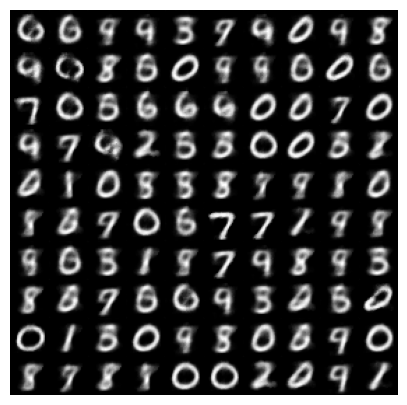

In [ ]:
# 생성 이미지 시각화
model.eval()

n = 100   # 생성할 이미지 수
generated_images = []

with torch.no_grad():
    for _ in range(n):
        z = torch.randn(1, latent_dim).to(device)   # 잠재 벡터
        img = model.decoder(z).cpu().squeeze().numpy()   # 이미지 생성
        generated_images.append(img)

plt.figure(figsize=(5, 5))
plt.subplots_adjust(wspace=0, hspace=0)

for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(generated_images[i], cmap='gray')
    plt.axis("off")

plt.show()

In [ ]:
# 예제 8.3 DCGAN 숫자 생성 MNIST

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
transform = transforms.Compose([
    transforms.ToTensor(),    # 텐서로 변환
    transforms.Normalize((0.5,), (0.5,))   # 정규화(-1 ~ 1)
])

dataset = datasets.MNIST(root="./data", train=True,
                               download=True, transform=transform)

print(dataset.data.shape)  # 학습 데이터 shape 확인

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

torch.Size([60000, 28, 28])


In [ ]:
# 소규모 MNIST 데이터셋 생성(6,000개 이미지 샘플)
class ImagesOnlySmallDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.size = len(dataset) // 10   # 크기 축소(1/10)

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]   # 레이블 제외
        return img

dataset_small = ImagesOnlySmallDataset(dataset)

print(len(dataset_small))   # 샘플 수 확인

6000


In [ ]:
# 데이터 로더 생성
train_loader = DataLoader(dataset_small, batch_size=32, shuffle=True)

In [ ]:
# 생성자 정의
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 7 * 7 * 128),
            nn.BatchNorm1d(7 * 7 * 128),
            nn.ReLU(True)
        )

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        x = self.deconv(x)
        return x

# 생성자 모델 생성
generator = Generator(latent_dim = 100).to(device)

In [ ]:
!pip install torchinfo

In [ ]:
# 모델 구조 요약
from torchinfo import summary

summary(generator, input_size=(1, 100))  # 배치 크기 1, 입력(100)

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 6272]                 --
│    └─Linear: 2-1                       [1, 6272]                 633,472
│    └─BatchNorm1d: 2-2                  [1, 6272]                 12,544
│    └─ReLU: 2-3                         [1, 6272]                 --
├─Sequential: 1-2                        [1, 1, 28, 28]            --
│    └─ConvTranspose2d: 2-4              [1, 32, 14, 14]           65,568
│    └─BatchNorm2d: 2-5                  [1, 32, 14, 14]           64
│    └─ReLU: 2-6                         [1, 32, 14, 14]           --
│    └─ConvTranspose2d: 2-7              [1, 1, 28, 28]            513
│    └─Tanh: 2-8                         [1, 1, 28, 28]            --
Total params: 712,161
Trainable params: 712,161
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.90
Input size (MB): 0.00
Forwar

In [ ]:
# 판별자 정의
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 3 * 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# 판별자 모델 생성
discriminator = Discriminator().to(device)

In [ ]:
# 모델 구조 요약
summary(discriminator, input_size=(1, 1, 28, 28))  # 배치 크기 1, 입력(28x28x1)

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 128, 3, 3]            --
│    └─Conv2d: 2-1                       [1, 32, 14, 14]           544
│    └─LeakyReLU: 2-2                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 64, 7, 7]             32,832
│    └─BatchNorm2d: 2-4                  [1, 64, 7, 7]             128
│    └─LeakyReLU: 2-5                    [1, 64, 7, 7]             --
│    └─Conv2d: 2-6                       [1, 128, 3, 3]            131,200
│    └─BatchNorm2d: 2-7                  [1, 128, 3, 3]            256
│    └─LeakyReLU: 2-8                    [1, 128, 3, 3]            --
├─Sequential: 1-2                        [1, 1]                    --
│    └─Flatten: 2-9                      [1, 1152]                 --
│    └─Dropout: 2-10                     [1, 1152]                 --
│  

In [ ]:
# 하이퍼파라미터 설정
bce_loss = nn.BCELoss()   # 손실 함수 이진 교차 엔트로피 사용

g_optimizer = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
# 학습 루프 함수 정의
def train_step(images):
    images = images.to(device)
    noise = torch.randn(images.size(0), latent_dim, device=device)

    # 판별자 학습
    real_output = discriminator(images)   # 진짜 이미지 출력
    fake_images = generator(noise)   # 가짜 이미지 생성
    fake_output = discriminator(fake_images.detach())   # 가짜 이미지 출력

    real_labels = torch.ones_like(real_output)   # 진짜 이미지 레이블(1)
    fake_labels = torch.zeros_like(fake_output)   # 가짜 이미지 레이블(0)

    real_loss = bce_loss(real_output, real_labels)   # 진짜 이미지 손실
    fake_loss = bce_loss(fake_output, fake_labels)   # 가짜 이미지 손실

    d_loss = real_loss + fake_loss   # 판별자 손실

    d_optimizer.zero_grad()   # 판별자 그레디언트 초기화
    d_loss.backward()   # 역전파
    d_optimizer.step()   # 최적화 수행

    # 생성자 학습
    fake_images = generator(noise)   # 가짜 이미지 생성
    fake_output = discriminator(fake_images)   # 가짜 이미지 출력

    g_labels = torch.ones_like(fake_output)   # 가짜 이미지 레이블 1로 지정
    g_loss = bce_loss(fake_output, g_labels)   # 생성자 손실

    g_optimizer.zero_grad()   # 생성자 그레디언트 초기화
    g_loss.backward()   # 역전파
    g_optimizer.step()   # 최적화 수행

    return d_loss.item(), g_loss.item()

In [ ]:
# 이미지 생성/저장 함수 정의
def generate_save_images(model, epoch, inputs, device):
    model.eval()   # 검증 모드

    with torch.no_grad():   # 예측할 때에는 자동 미분하지 않음
        prediction = model(inputs.to(device)).cpu()   # 이미지 생성

    # 생성 이미지 시각화
    min_val = torch.min(prediction)
    max_val = torch.max(prediction)
    prediction = (prediction - min_val) / (max_val - min_val)   # 정규화(0~1)

    plt.figure(figsize=(5,5))
    plt.subplots_adjust(wspace=0, hspace=0)

    for i in range(prediction.shape[0]):
        plt.subplot(10, 10, i + 1)
        img = prediction[i, 0, :, :]   # 채널 제거
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.savefig(f"image_at_epoch_{epoch}.png")   # 이미지 저장
    plt.show()

    model.train()

In [ ]:
# 학습 함수 정의
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # 에포크마다 이미지 생성/저장
        display.clear_output(wait=True)
        print(f"generated images at epoch {epoch + 1}")
        generate_save_images(generator, epoch + 1, seed, device)

generated images at epoch 50


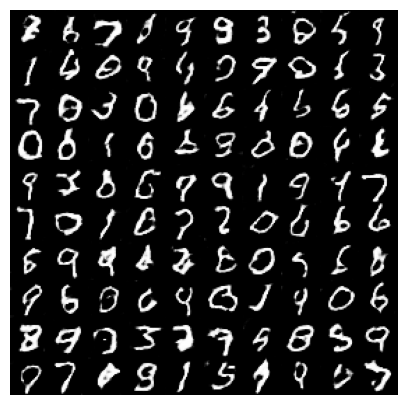

In [ ]:
# 학습(이미지 생성)
epochs = 50
latent_dim = 100   # 랜덤 벡터 차원
num_generate = 100   # 생성할 이미지 수

seed = torch.randn(num_generate, latent_dim, device=device)   # 생성자 학습 시작 입력

train(train_loader, epochs)

# 예제 8.4

https://commons.wikimedia.org/wiki/File:VanGogh-starry_night_ballance1.jpg

In [ ]:
# 예제 8.4 스타일 전이

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import torch
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torchvision.models import vgg19, VGG19_Weights
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 콘텐츠 이미지(강아지 사진)/스타일 이미지(고흐 그림) 준비
content_path = "/content/drive/MyDrive/Datasets/강아지 사진.png"
style_path = "/content/drive/MyDrive/Datasets/고흐 별이빛나는밤에.jpg"

content_img = Image.open(content_path).convert("RGB")
style_img = Image.open(style_path).convert("RGB")

print(f" size of content image: {content_img.size}")   # 콘텐츠 이미지 크기 확인
print(f" size of style image: {style_img.size}")   # 스타일 이미지 크기 확인

 size of content image: (1024, 1024)
 size of style image: (1280, 1022)


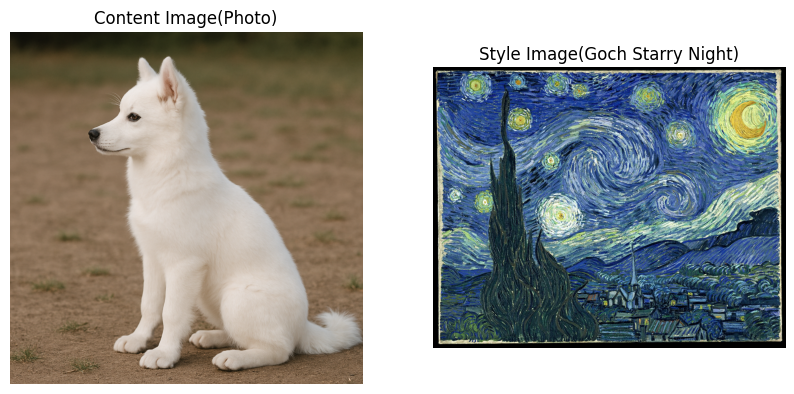

In [ ]:
# 콘텐츠 이미지/스타일 이미지 시각화
plt.figure(figsize=(10,10))

plt.subplot(1, 2, 1)
plt.imshow(content_img)
plt.title("Content Image(Photo)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_img)
plt.title("Style Image(Goch Starry Night)")
plt.axis("off")

plt.show()

In [ ]:
# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # 이미지 크기 조정
    transforms.ToTensor(),   # 텐서 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # 정규화
])

content_image = transform(content_img).unsqueeze(0).to(device)
style_image = transform(style_img).unsqueeze(0).to(device)

print(f" shape of content image: {content_image.shape}")   # 이미지 shape 확인
print(f" shaspe of style image: {style_image.shape}")

 shape of content image: torch.Size([1, 3, 128, 128])
 shaspe of style image: torch.Size([1, 3, 128, 128])


In [ ]:
# VGG19 모델 불러오기
model = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(device)
model = model.eval()   # 평가 모드로 가중치 동결

In [ ]:
# 모델의 계층 구조 확인
model._modules

{'0': Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '1': ReLU(inplace=True),
 '2': Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '3': ReLU(inplace=True),
 '4': MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 '5': Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '6': ReLU(inplace=True),
 '7': Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '8': ReLU(inplace=True),
 '9': MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 '10': Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '11': ReLU(inplace=True),
 '12': Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '13': ReLU(inplace=True),
 '14': Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '15': ReLU(inplace=True),
 '16': Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
 '17': ReLU(inplace=True),
 '18': MaxPool2d(kernel_si

In [ ]:
# 손실 계산에 사용할 계층의 출력(특징) 함수 정의
layers = {"0": "block1_conv1",
          "5": "block2_conv1",
          "10": "block3_conv1",
          "19": "block4_conv1",
          "21": "block5_conv1",
          "28": "block5_conv2"}

def get_features(x):
    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

In [ ]:
# 그람 행렬 함수 정의
def gram_matrix(input):
    batch, channel, height, width = input.size()
    features = input.view(channel, height * width)   # 높이x너비 벡터 생성
    G = torch.matmul(features, features.t())   # 내적 계산
    G = G / (channel * height * width)   # 정규화
    return G

In [ ]:
# 모델 학습
stylized_image = content_image.clone().requires_grad_(True).to(device)

optimizer = torch.optim.Adam(
    [stylized_image], lr=0.1)   # 스타일 전이 이미지를 학습

step = 200
content_weight = 1
style_weight = 1e6

content_layer = "block5_conv2"
style_layers = ["block1_conv1", "block2_conv1", "block3_conv1",
                "block4_conv1", "block5_conv1"]

with torch.no_grad():   # 그레디언트 계산하지 않음
    content_f = get_features(content_image)
    style_f = get_features(style_image)

content_losses = []
style_losses = []
total_losses = []

for i in range(step):
    stylized_f = get_features(stylized_image)

    # 콘텐츠 손실
    content_loss = F.mse_loss(stylized_f["block5_conv2"],   # 콘텐츠 특징
                              content_f["block5_conv2"])   # 콘텐츠 표현

    # 스타일 손실
    style_loss = 0

    for l in style_layers:
        G = gram_matrix(stylized_f[l])   # 스타일 특징
        S = gram_matrix(style_f[l])   # 스타일 표현

        style_loss += F.mse_loss(G, S)

    # 전체 손실
    loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()   # 그레디언트 초기화
    loss.backward()   # 그레디언트 계산
    optimizer.step()   # 최적화 수행

    if i == 0 or (i + 1) % 50 == 0:
        print(f"step: {i + 1} \t content loss: {content_loss.item():.4f}"
              f" \t style loss: {style_loss.item():.4f} \t total loss: {loss.item():.4f}")

step: 1 	 content loss: 0.0000 	 style loss: 0.0008 	 total loss: 819.0669
step: 50 	 content loss: 9.8126 	 style loss: 0.0000 	 total loss: 50.4717
step: 100 	 content loss: 9.2865 	 style loss: 0.0000 	 total loss: 29.0111
step: 150 	 content loss: 9.0101 	 style loss: 0.0000 	 total loss: 21.9729
step: 200 	 content loss: 8.7262 	 style loss: 0.0000 	 total loss: 18.8072


In [ ]:
# 스타일 전이 이미지 저장
save_image(stylized_image, "/content/drive/MyDrive/stylized_image.png")

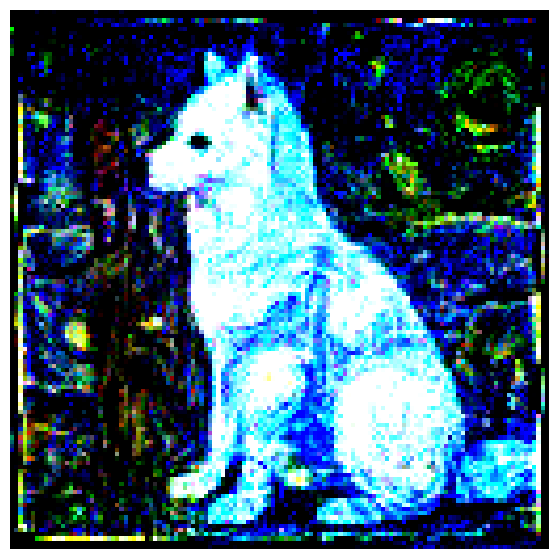

In [ ]:
# 생성된 이미지 시각화
stylized_img = stylized_image.detach().cpu()
stylized_img = stylized_img.squeeze(0).permute(1, 2, 0).clamp(0,1)

plt.figure(figsize=(7,7))
plt.imshow(stylized_img)
plt.axis("off")
plt.show()

In [ ]:
# 예제 8.5 이미지 생성(허깅페이스 Stable Diffusion)

from huggingface_hub import login

# login(token="hf_***")

In [ ]:
!pip install diffusers  --quiet

In [ ]:
# 셋업
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

In [ ]:
# 이미지 생성 파이프라인
pipe = StableDiffusionPipeline.from_pretrained(
    "sd-legacy/stable-diffusion-v1-5").to(device="cuda")   # GPU 필수

 # stabilityai/stable-diffusion-3.5-medium  CompVis/stable-diffusion-v1-4

In [ ]:
# 이미지 생성
generator = torch.Generator("cuda").manual_seed(77)   # 제너레이터 생성

prompt = "Pikachu walking on the busy street"

generated_image = pipe(
    prompt,
    negative_prompt="blurry, low quality, bad anatomy",
    height=512,
    width=512,
    num_inference_steps=40,   # 타임 스텝
    guidance_scale=7,   # 프롬프트 충실도
    num_images_per_prompt=2,   # 생성할 이미지 수
    generator=generator   # 난수 생성기(동일한 결과 재현)
).images   # PIL 이미지 리스트 출력

  0%|          | 0/40 [00:00<?, ?it/s]

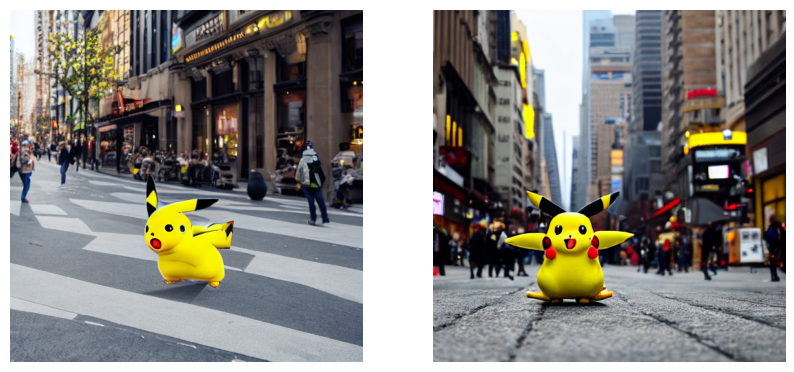

In [ ]:
# 생성 이미지 시각화
plt.figure(figsize=(10, 10))

for i, img in enumerate(generated_image):
    plt.subplot(1, 2 ,i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
# 예제 8.6 이미지 변환(허깅페이스 Stable Diffusion)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 허깅페이스 로그인
from huggingface_hub import login

# login(token="hf_***")

In [ ]:
!pip install diffusers  --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.4 MB/s eta 0:00:00


In [ ]:
# 셋업
import torch
from diffusers import StableDiffusionXLImg2ImgPipeline
from diffusers.utils import load_image
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 이미지 변환 파이프라인
pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True).to("cuda")

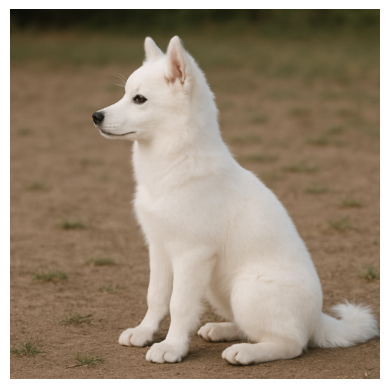

In [ ]:
# 원본 이미지 시각화
file_path = "/content/drive/MyDrive/Datasets/강아지 사진.png"

with Image.open(file_path) as img:
    img = img.convert("RGB").resize((512, 512))

    plt.imshow(img)
    plt.axis("off")

    plt.show()

In [ ]:
# 이미지 변환

generator = torch.Generator("cuda").manual_seed(7)   # 제너레이터 생성

prompt = "Turn this dog into a cat"

image = pipe(
    prompt=prompt,
    image=img,
    strength=1,   # 원본 변형 강도
    guidance_scale=50,   # 프롬프트 충실도
    generator=generator   # 난수 생성기(동일한 결과 재현)
).images   # PIL 이미지 리스트 출력

  0%|          | 0/50 [00:00<?, ?it/s]

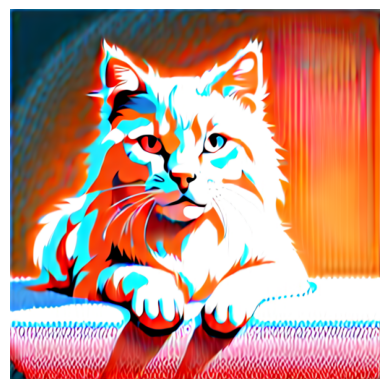

In [ ]:
# 생성 이미지 시각화
plt.imshow(image[0])
plt.axis("off")

plt.show()

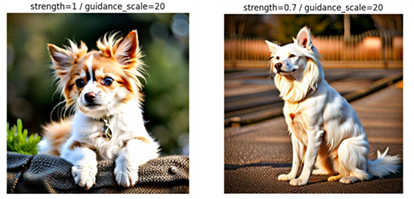

In [ ]:
# 이미지 변환
generator = torch.Generator("cuda").manual_seed(77)   # 초기 잡음을 위한 난수 생성

prompt = "Turn this dog in a Ghibli style"

image = pipe(
    prompt=prompt,
    image=img,
    strength=0.7,   # 원본 변형 강도
    guidance_scale=20,   # 프롬프트 충실도
    generator=generator   # 난수 생성기(동일한 결과 재현)
).images   # PIL 이미지 리스트 출력

  0%|          | 0/35 [00:00<?, ?it/s]

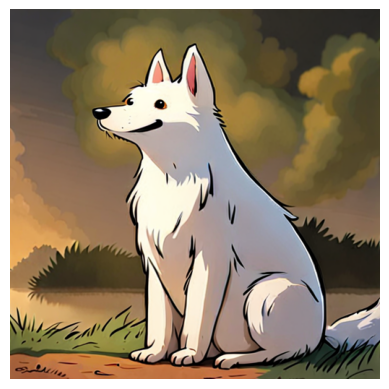

In [ ]:
# 생성 이미지 시각화
plt.imshow(image[0])
plt.axis("off")

plt.show()